# KrediTahmin: Kredi Onayı Tahmin Modeli

Bu notebook, kapanış projesi olarak geliştirdiğim **KrediTahmin** web uygulamasının arkasındaki modeli eğitiyor.

**Problem:** Bir bankaya kredi başvurusu yapan kişinin gelir, varlık, kredi skoru ve kredi bilgilerine bakarak başvurunun **onaylanıp onaylanmayacağını** tahmin etmek. Bu bir **sınıflandırma** problemi.

Veri seti: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

**Yol haritası:**
1. Veriyi tanıma
2. Veri temizliği
3. EDA (keşifsel veri analizi)
4. Feature engineering
5. Baseline: tek kural ile tahmin
6. Tüm sınıflandırma modellerini deneme (feature engineering öncesi ve sonrası)
7. Transformation kontrolü
8. Hyperparameter tuning
9. Final model ve değerlendirme
10. Modeli anlamak
11. Modeli kaydetme (.pkl) → web uygulamasında kullanılacak

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

## 1. Veriyi Tanıma

Kaggle'da veri setinin yolu değişebildiği için dosyayı `glob` ile buluyoruz:

In [3]:
import glob

path = glob.glob("/kaggle/input/**/loan_approval_dataset.csv", recursive=True)[0]
df = pd.read_csv(path)

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
df.shape

(4269, 13)

In [6]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

Sütun isimlerinin başında **boşluk** var (ör. `' cibil_score'`). Bu, `df["cibil_score"]` yazdığımızda hata almamıza sebep olur.
Kategorik değerlerin başında da boşluk var (`' Graduate'`, `' Approved'`). Veri temizliğinde ikisini de düzelteceğiz.

**Sütunlar:**
- `loan_id`: başvuru numarası
- `no_of_dependents`: bakmakla yükümlü olunan kişi sayısı
- `education`: eğitim durumu (Graduate / Not Graduate)
- `self_employed`: kendi işinin sahibi mi?
- `income_annum`: yıllık gelir
- `loan_amount`: istenen kredi tutarı
- `loan_term`: kredi vadesi (yıl)
- `cibil_score`: kredi skoru (300-900). Hindistan'daki kredi notu sistemi, Türkiye'deki Findeks notuna benziyor.
- `residential_assets_value`, `commercial_assets_value`, `luxury_assets_value`, `bank_asset_value`: konut, ticari, lüks varlıklar ve banka varlıkları
- `loan_status`: kredi onaylandı mı? → **tahmin etmeye çalıştığımız değer (y)**

Tutarlar Hint Rupisi (₹) cinsinden.

## 2. Veri Temizliği

In [7]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].str.strip()

df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [9]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

Eksik değer ve tekrar eden satır yok. Sayısal değerlerin mantıklı aralıkta olup olmadığına bakalım:

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


`residential_assets_value` (konut varlığı) sütununun minimum değeri **negatif**. Bir varlığın değeri negatif olamaz, bu bir veri hatası. Kaç satırda olduğuna bakalım:

In [12]:
print((df.select_dtypes(include=np.number) < 0).sum())
df[df["residential_assets_value"] < 0]["residential_assets_value"].value_counts()

loan_id                      0
no_of_dependents             0
income_annum                 0
loan_amount                  0
loan_term                    0
cibil_score                  0
residential_assets_value    28
commercial_assets_value      0
luxury_assets_value          0
bank_asset_value             0
dtype: int64


residential_assets_value
-100000    28
Name: count, dtype: int64

28 satırda değer **-100.000**. Hepsi aynı değer olduğu için büyük ihtimalle veri girişindeki bir hatayı ya da "konutu yok" bilgisini temsil ediyor.
Satırları silmek yerine bu değerleri **0** yapıyoruz (yani "konut varlığı yok").

In [13]:
df.loc[df["residential_assets_value"] < 0, "residential_assets_value"] = 0
df["residential_assets_value"].min()

np.int64(0)

`loan_id` sadece bir numara olduğu için modele bir bilgi katmıyor, çıkarıyoruz:

In [14]:
df = df.drop("loan_id", axis=1)

## 3. EDA (Keşifsel Veri Analizi)

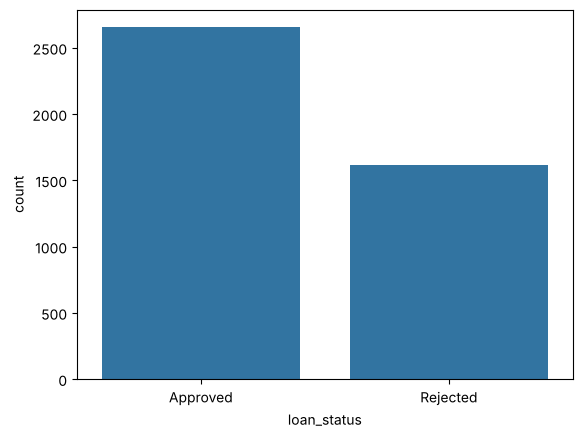

In [15]:
sns.countplot(data=df, x="loan_status")
plt.show()

In [16]:
df["loan_status"].value_counts(normalize=True)

loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64

Başvuruların yaklaşık **%62'si onaylanmış, %38'i reddedilmiş**. Hafif bir dengesizlik var ama Telco projesindeki gibi ciddi değil.

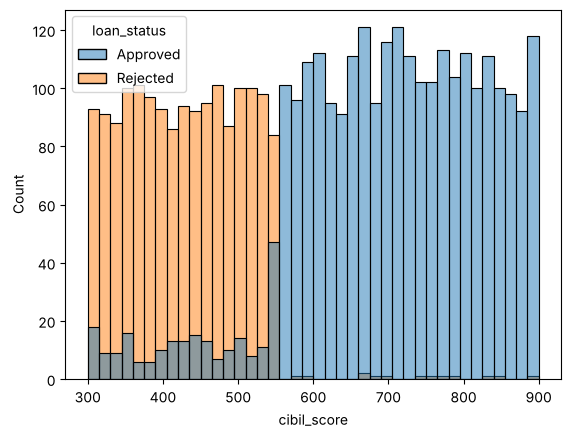

In [17]:
sns.histplot(data=df, x="cibil_score", hue="loan_status", bins=40)
plt.show()

Bu grafik projenin en önemli bulgusu. **Kredi skoru 550 civarında keskin bir sınır var:**
- 550'nin üstündeki başvuruların neredeyse hepsi onaylanmış.
- 550'nin altındakilerin büyük kısmı reddedilmiş.

Kredi skoru aralıklarına göre onay oranlarına bakalım:

In [18]:
cibil_groups = pd.cut(df["cibil_score"], bins=[299, 400, 500, 550, 600, 700, 800, 900])
df.groupby(cibil_groups)["loan_status"].apply(lambda s: (s == "Approved").mean()).to_frame("Onay oranı")

,Onay oranı
cibil_score,
"(299, 400]",0.101124
"(400, 500]",0.112392
"(500, 550]",0.101828
"(550, 600]",0.994366
"(600, 700]",0.994286
"(700, 800]",0.994550
"(800, 900]",0.995658


550 altında onay oranı yaklaşık **%10**, 550 üstünde ise **%99'un üzerinde**.

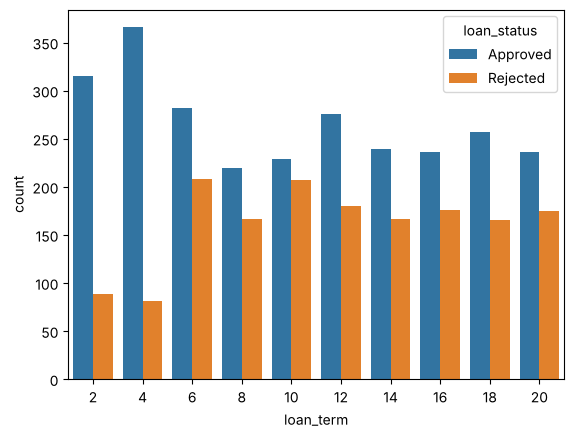

In [19]:
sns.countplot(data=df, x="loan_term", hue="loan_status")
plt.show()

Vadesi 2-4 yıl olan kısa vadeli kredilerin onaylanma oranı belirgin şekilde daha yüksek. Kısa vadede bankanın riski daha düşük.

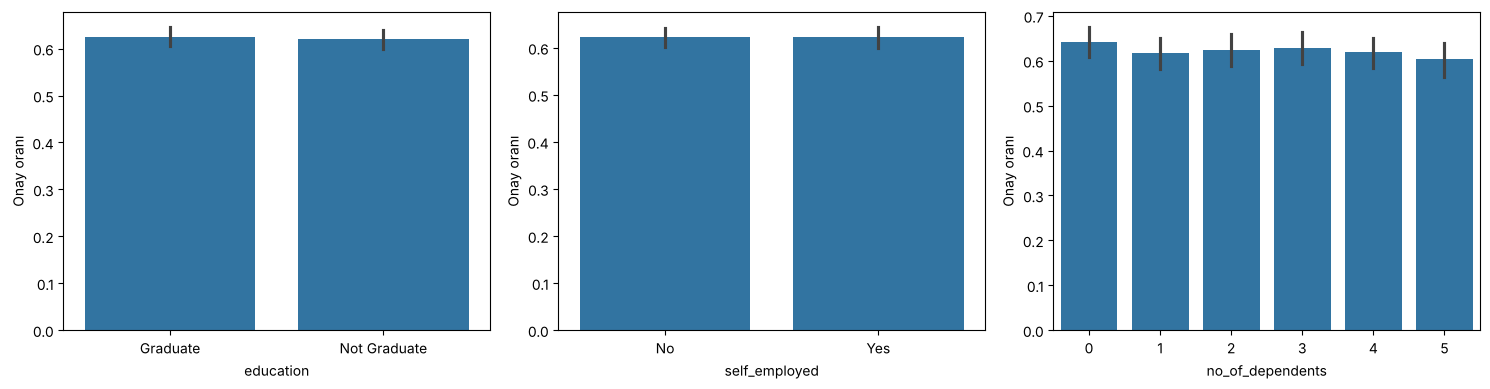

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.barplot(data=df, x="education", y=(df["loan_status"] == "Approved").astype(int))
plt.ylabel("Onay oranı")

plt.subplot(1, 3, 2)
sns.barplot(data=df, x="self_employed", y=(df["loan_status"] == "Approved").astype(int))
plt.ylabel("Onay oranı")

plt.subplot(1, 3, 3)
sns.barplot(data=df, x="no_of_dependents", y=(df["loan_status"] == "Approved").astype(int))
plt.ylabel("Onay oranı")

plt.tight_layout()
plt.show()

Eğitim durumu, kendi işinin sahibi olma ve bakmakla yükümlü olunan kişi sayısının onay oranına **hiçbir etkisi yok**; tüm gruplarda oran %62 civarında.

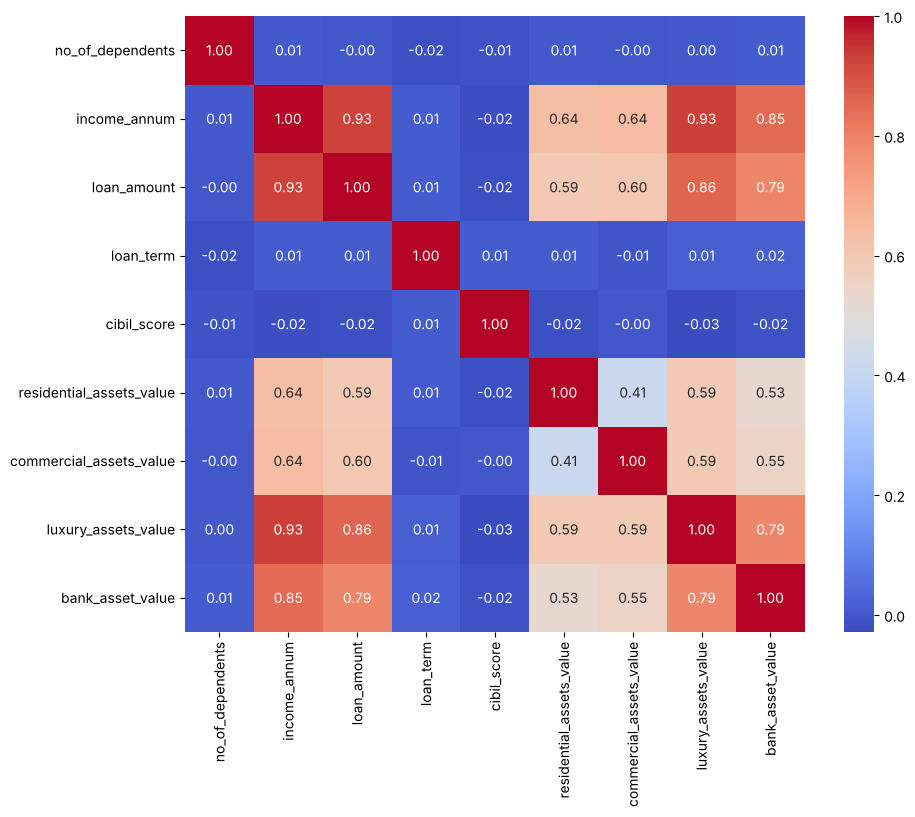

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

- `income_annum` ile `loan_amount` (0.93) ve `luxury_assets_value` (0.93) çok güçlü ilişkili. Geliri yüksek olan hem daha çok kredi istiyor hem de daha çok lüks varlığa sahip.
- Varlık sütunları da birbiriyle ve gelirle güçlü ilişkili.

Bu değişkenler birbirine bu kadar benzediği için tek başlarına çok bilgi taşımıyor olabilir. Asıl bilgi **oranlarında** saklı olabilir: gelire göre ne kadar kredi istendiği gibi. Feature engineering kısmında buna bakacağız.

## 4. Feature Engineering

Bankalar kredi verirken ham tutarlardan çok **oranlara** bakar. Örneğin aynı 1 milyonluk kredi, yıllık geliri 10 milyon olan biri için küçük, 1 milyon olan biri için çok büyük bir yüktür.
Bu yüzden şu yeni feature'ları türetiyoruz:

- **`total_assets`**: Toplam varlık (konut + ticari + lüks + banka)
- **`loan_to_income`**: Kredi tutarı / yıllık gelir. Kişi kaç yıllık gelirini kredi olarak istiyor?
- **`loan_to_assets`**: Kredi tutarı / toplam varlık. Kredinin ne kadarı varlıklarla karşılanabilir?
- **`yearly_payment_to_income`**: (Kredi tutarı / vade) / yıllık gelir. Yani **yıllık taksitin gelire oranı**. Bankacılıkta "borç servis oranı" olarak bilinen, kişinin gelirinin ne kadarını kredi ödemesine ayıracağını gösteren temel bir ölçü.

Bu dönüşümü bir fonksiyon olarak yazıyoruz. **Aynı fonksiyonu web uygulamasında da kullanacağız**, böylece model kullanıcıdan gelen veriyi eğitimdekiyle tamamen aynı şekilde görecek.

In [22]:
def add_features(data):
    data = data.copy()
    asset_cols = ["residential_assets_value", "commercial_assets_value", "luxury_assets_value", "bank_asset_value"]
    data["total_assets"] = data[asset_cols].sum(axis=1)
    data["loan_to_income"] = data["loan_amount"] / data["income_annum"]
    data["loan_to_assets"] = data["loan_amount"] / data["total_assets"].replace(0, 1)
    data["yearly_payment_to_income"] = (data["loan_amount"] / data["loan_term"]) / data["income_annum"]
    return data

`total_assets` sıfır olursa sıfıra bölme hatası olmasın diye paydadaki 0 değerini 1 yapıyoruz. Bu veride toplam varlığı 0 olan kimse yok ama web uygulamasında kullanıcı bütün varlıkları 0 girebilir.

Kategorik iki sütunu da 0/1'e çeviriyoruz. Bu eşlemeleri modelle birlikte kaydedeceğiz:

In [23]:
education_map = {"Graduate": 1, "Not Graduate": 0}
self_employed_map = {"Yes": 1, "No": 0}

df["education"] = df["education"].map(education_map)
df["self_employed"] = df["self_employed"].map(self_employed_map)
df["loan_status"] = (df["loan_status"] == "Approved").astype(int)

df = add_features(df)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets,loan_to_income,loan_to_assets,yearly_payment_to_income
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000,3.114583,0.589744,0.259549
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000,2.975610,0.717647,0.371951
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000,3.263736,0.514731,0.163187
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000,3.743902,0.582543,0.467988
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000,2.469388,0.440000,0.123469


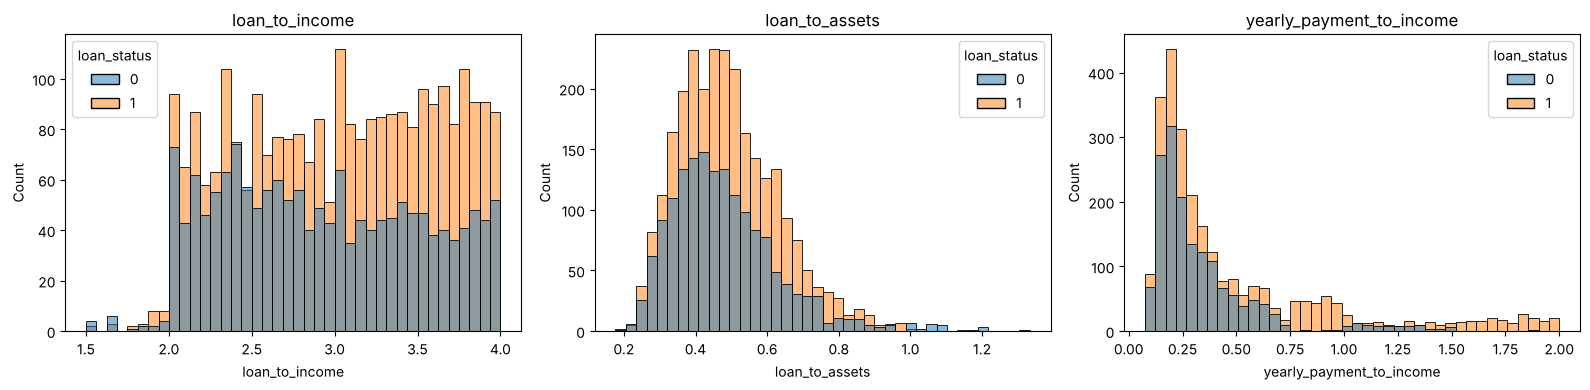

In [24]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
for i, col in enumerate(["loan_to_income", "loan_to_assets", "yearly_payment_to_income"], 1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df, x=col, hue="loan_status", bins=40)
    plt.title(col)
plt.tight_layout()
plt.show()

Tek başına bakınca yeni feature'lar onaylanan ve reddedilenleri net ayırmıyor gibi görünüyor. Ama kredi skoru ile **birlikte** değerlendirildiğinde işe yarıyorlar.
Kredi skoru 550'nin altında olan başvurulara bakalım:

In [25]:
low_cibil = df[df["cibil_score"] < 550]
ratio_groups = pd.cut(low_cibil["yearly_payment_to_income"], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0])
low_cibil.groupby(ratio_groups)["loan_status"].agg(["mean", "count"]).rename(columns={"mean": "Onay oranı", "count": "Başvuru sayısı"})

,Onay oranı,Başvuru sayısı
yearly_payment_to_income,,
"(0.0, 0.2]",0.000000,552
"(0.2, 0.4]",0.000000,657
"(0.4, 0.6]",0.000000,219
"(0.6, 0.8]",0.213592,103
"(0.8, 1.0]",0.942529,87
"(1.0, 2.0]",0.485030,167


Kredi skoru düşük olan başvurularda onay, **yıllık taksit/gelir oranına** bağlı: oran 0.6'nın altındayken hiçbir başvuru onaylanmamış, 0.8-1.0 aralığında ise başvuruların çoğu onaylanmış.

Gerçek hayatta yüksek taksit yükünün onay şansını *artırması* beklenmez. Bu desen büyük ihtimalle verinin kısa vadeli kredilerle (2-4 yıl) ilişkisinden geliyor: kısa vadede yıllık taksit doğal olarak yüksek çıkıyor. Ayrıca bu veri seti gerçek banka verisi değil, büyük ihtimalle kurallarla üretilmiş (sentetik) bir veri. Bu yüzden modelin öğrendiği kuralları gerçek bankacılık kararları gibi yorumlamamak gerekiyor.

## 5. Train / Test Ayrımı ve Baseline

In [26]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)
X_train.shape, X_test.shape

((3415, 15), (854, 15))

Modellere geçmeden önce bir **baseline** belirleyelim: hiç makine öğrenmesi kullanmadan, sadece "kredi skoru 550 ve üstüyse onayla" kuralı ne kadar başarılı?

In [28]:
from sklearn.metrics import accuracy_score

rule_pred = (X_test["cibil_score"] >= 550).astype(int)
baseline_accuracy = accuracy_score(y_test, rule_pred)
baseline_accuracy

0.9578454332552693

Tek bir kural bile test setinde yaklaşık **%95.8** doğruluk veriyor. Modellerimizin değerini bu sayıyı ne kadar geçtiğine göre ölçeceğiz.

## 6. Tüm Sınıflandırma Modellerini Deneme

In [29]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

Logistic Regression, SVM ve KNN ölçeğe duyarlı olduğu için onları `StandardScaler` ile birlikte bir pipeline içine koyuyoruz. Ağaç tabanlı modeller ölçekten etkilenmez.

Sonuçların şansa bağlı olmaması için her modeli train verisi üzerinde **5-fold cross validation** ile değerlendiriyoruz.

In [30]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=15)

def get_models():
    return {
        "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
        "SVM": make_pipeline(StandardScaler(), SVC()),
        "Naive Bayes": GaussianNB(),
        "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
        "Decision Tree": DecisionTreeClassifier(random_state=15),
        "Random Forest": RandomForestClassifier(random_state=15),
        "AdaBoost": AdaBoostClassifier(random_state=15),
        "Gradient Boosting": GradientBoostingClassifier(random_state=15),
        "XGBoost": XGBClassifier(random_state=15),
        "LightGBM": LGBMClassifier(random_state=15, verbosity=-1)
    }

def evaluate_models(X_tr):
    results = {}
    for name, model in get_models().items():
        results[name] = cross_val_score(model, X_tr, y_train, cv=skf, scoring="accuracy").mean()
    return pd.Series(results)

Önce **feature engineering olmadan**, sadece orijinal sütunlarla deneyelim:

In [31]:
new_features = ["total_assets", "loan_to_income", "loan_to_assets", "yearly_payment_to_income"]

results_without_fe = evaluate_models(X_train.drop(new_features, axis=1))
results_with_fe = evaluate_models(X_train)

comparison = pd.DataFrame({
    "FE olmadan": results_without_fe,
    "FE ile": results_with_fe
})
comparison["Fark"] = comparison["FE ile"] - comparison["FE olmadan"]
comparison.sort_values("FE ile", ascending=False)

,FE olmadan,FE ile,Fark
Gradient Boosting,0.978331,0.999122,0.020791
Decision Tree,0.971596,0.999122,0.027526
LightGBM,0.983602,0.999122,0.015520
AdaBoost,0.966032,0.998829,0.032796
Random Forest,0.977452,0.998243,0.020791
XGBoost,0.982138,0.997657,0.015520
SVM,0.938799,0.954319,0.015520
Logistic Regression,0.916837,0.935871,0.019034
KNN,0.885798,0.891654,0.005857
Naive Bayes,0.763104,0.626647,-0.136457


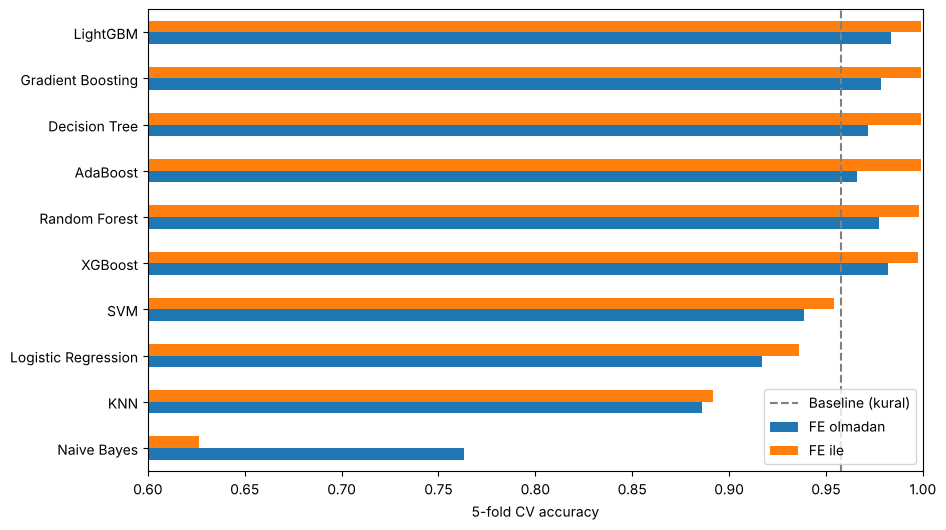

In [32]:
comparison.sort_values("FE ile").plot(kind="barh", y=["FE olmadan", "FE ile"], figsize=(10, 6))
plt.axvline(baseline_accuracy, color="gray", linestyle="--", label="Baseline (kural)")
plt.xlim(0.6, 1.0)
plt.xlabel("5-fold CV accuracy")
plt.legend()
plt.show()

**Feature engineering bu projenin en büyük kazancı oldu:**
- Feature engineering olmadan en iyi model (LightGBM) yaklaşık **%98.4**'te kalıyordu.
- Yeni oranlarla **Gradient Boosting, Decision Tree ve LightGBM %99.9**'a çıktı. Hata oranı yaklaşık 20 kat azaldı.
- Ağaç tabanlı modellerin hepsi 1.5-3.3 puan kazandı. Logistic Regression ve SVM de yaklaşık 2 puan iyileşti.

Neden bu kadar işe yaradı? Ağaç modelleri değişkenleri tek tek eşiklerle böler. "Kredi tutarı / vade / gelir" gibi **üç değişkenin birlikte oluşturduğu** bir ilişkiyi ham sütunlardan yakalamak için çok sayıda bölme yapmaları gerekiyordu. Biz bu oranı hazır verince model onu tek bir bölmeyle kullanabildi.

**Tek istisna Naive Bayes** oldu: %76'dan %63'e düştü. %63 aslında "herkese onay ver" demekle aynı (onay oranı %62). Naive Bayes değişkenlerin birbirinden bağımsız ve normal dağılımlı olduğunu varsayıyor. Yeni feature'lar mevcut sütunlardan türetildiği için onlarla güçlü bir şekilde ilişkili, ayrıca `yearly_payment_to_income` çok çarpık. Bu iki varsayım da bozulunca model çöküyor.

**KNN** ise baseline'ın (%95.8) bile altında kalıyor. 15 boyutlu uzayda bütün değişkenlere eşit ağırlıkla mesafe ölçtüğü için, en önemli değişken olan kredi skorunun etkisi kayboluyor.

## 7. Transformation Kontrolü

In [33]:
from scipy.stats import skew

X_train.apply(skew).sort_values(ascending=False)

yearly_payment_to_income    2.030726
loan_to_assets              1.032182
residential_assets_value    0.970465
commercial_assets_value     0.959690
bank_asset_value            0.539659
luxury_assets_value         0.325396
loan_amount                 0.305766
total_assets                0.302175
loan_term                   0.037979
cibil_score                 0.001705
education                  -0.001757
income_annum               -0.007590
loan_to_income             -0.014083
no_of_dependents           -0.023882
self_employed              -0.035730
dtype: float64

Çarpıklığı belirgin olan tek değişken `yearly_payment_to_income` (yaklaşık 2). Varlık sütunları ise 1'in altında, orta düzeyde.

Ağaç tabanlı modeller transformation'dan etkilenmez; bunu Telco projesinde de görmüştük. Lineer modelde bir fark yaratıp yaratmadığını deneyelim:

In [34]:
from sklearn.preprocessing import PowerTransformer

lr_scaler = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
lr_yeo = make_pipeline(PowerTransformer(method="yeo-johnson"), LogisticRegression(max_iter=3000))

print("Logistic Regression - StandardScaler:", round(cross_val_score(lr_scaler, X_train, y_train, cv=skf).mean(), 4))
print("Logistic Regression - Yeo-Johnson   :", round(cross_val_score(lr_yeo, X_train, y_train, cv=skf).mean(), 4))

Logistic Regression - StandardScaler: 0.9359


Logistic Regression - Yeo-Johnson   : 0.9165


Yeo-Johnson, Logistic Regression'ı **iyileştirmedi, tam tersine düşürdü** (%93.6 → %91.7). California Housing ödevinde transformation lineer modele yaramıştı, burada yaramadı.

Sebebi şu: modelin en çok ihtiyaç duyduğu bilgi, kredi skorunun 550'deki **keskin eşiği** ve taksit oranındaki belirli aralıklar. Yeo-Johnson dağılımı sıkıştırıp normale yaklaştırırken bu aralıklar arasındaki farkları da küçültüyor. Ağaç modelleri zaten transformation'dan etkilenmediği için bu adımı final modelde kullanmıyoruz.

**Ders:** Transformation her zaman işe yaramaz. Her veri seti için denemek ve ölçmek gerekiyor.

## 8. Hyperparameter Tuning

En iyi sonuç veren ağaç tabanlı modelleri `RandomizedSearchCV` ile optimize ediyoruz.
LightGBM'de `n_jobs=1` veriyoruz, yoksa RandomizedSearchCV'nin paralelliği ile çakışıp takılabiliyor (Telco projesinde yaşamıştık).

In [35]:
from sklearn.model_selection import RandomizedSearchCV

In [36]:
param_grids = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=15),
        {
            "max_depth": [3, 4, 5, 6, 8, 10, None],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "criterion": ["gini", "entropy"]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=15),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 8, 12, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", None]
        }
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=15),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.5, 1.0]
        }
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=15),
        {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [2, 3, 4, 5],
            "subsample": [0.8, 1.0],
            "min_samples_leaf": [1, 5, 10]
        }
    ),
    "XGBoost": (
        XGBClassifier(random_state=15),
        {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [2, 3, 4, 5, 6],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0]
        }
    ),
    "LightGBM": (
        LGBMClassifier(random_state=15, verbosity=-1, n_jobs=1),
        {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "num_leaves": [7, 15, 31],
            "max_depth": [3, 5, -1],
            "min_child_samples": [10, 20, 50],
            "colsample_bytree": [0.6, 0.8, 1.0]
        }
    )
}

Bu hücre birkaç dakika sürebilir:

In [37]:
best_models = {}
tuning_results = []

for name, (model, params) in param_grids.items():
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=15,
        cv=skf,
        scoring="accuracy",
        random_state=15,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    best_models[name] = random_search.best_estimator_
    tuning_results.append({
        "Model": name,
        "Tuning öncesi CV": results_with_fe[name],
        "Tuning sonrası CV": random_search.best_score_,
        "Test accuracy": accuracy_score(y_test, random_search.predict(X_test))
    })
    print(name, "->", random_search.best_params_)

Decision Tree -> {'min_samples_split': 2, 'min_samples_leaf': 10, 'max_depth': 6, 'criterion': 'entropy'}


Random Forest -> {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


AdaBoost -> {'n_estimators': 200, 'learning_rate': 1.0}


Gradient Boosting -> {'subsample': 1.0, 'n_estimators': 300, 'min_samples_leaf': 10, 'max_depth': 2, 'learning_rate': 0.05}


XGBoost -> {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


LightGBM -> {'num_leaves': 7, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [38]:
tuning_results = pd.DataFrame(tuning_results).sort_values("Tuning sonrası CV", ascending=False).reset_index(drop=True)
tuning_results

,Model,Tuning öncesi CV,Tuning sonrası CV,Test accuracy
0,Gradient Boosting,0.999122,0.999707,0.997658
1,AdaBoost,0.998829,0.999414,0.997658
2,LightGBM,0.999122,0.999414,0.998829
3,Decision Tree,0.999122,0.999122,0.997658
4,Random Forest,0.998243,0.999122,0.998829
5,XGBoost,0.997657,0.997657,0.997658


- Tuning öncesinde de modeller %99.8-99.9 seviyesindeydi; tuning ancak küçük bir iyileştirme sağlayabildi.
- **Gradient Boosting** CV skorunda %99.91'den **%99.97**'ye çıktı ve ilk sıraya yerleşti. Seçilen parametreler sığ ağaçlar (`max_depth=2`) ve düşük learning rate (0.05). Bu da modelin overfit olmadan genelleştiğini gösteriyor.
- Test setinde modellerin hepsi **%99.77-99.88** aralığında. Yani 854 test başvurusundan sadece 1-2 tanesini yanlış tahmin ediyorlar.

Bu seviyede modeller arasındaki farklar artık 1-2 başvuruluk, yani istatistiksel olarak anlamlı değil.

## 9. Final Model

Final modeli **CV skoru en yüksek** olan model olarak seçiyoruz (test skoruna göre seçmek, test setine "bakmak" olur).

In [39]:
final_name = tuning_results.loc[0, "Model"]
final_model = best_models[final_name]
final_name

'Gradient Boosting'

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"], digits=4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

              precision    recall  f1-score   support

    Rejected     0.9969    0.9969    0.9969       323
    Approved     0.9981    0.9981    0.9981       531

    accuracy                         0.9977       854
   macro avg     0.9975    0.9975    0.9975       854
weighted avg     0.9977    0.9977    0.9977       854

ROC AUC: 0.9981


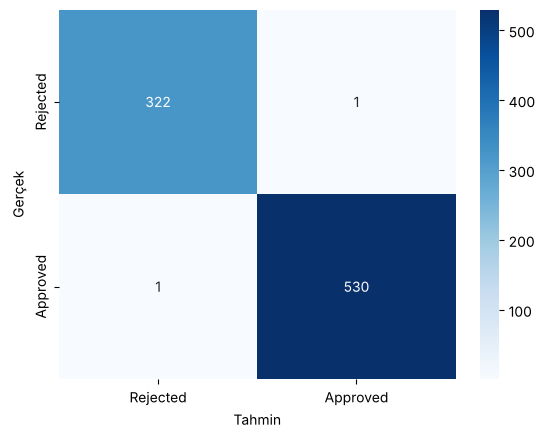

In [41]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()

Final model **Gradient Boosting**:
- Test accuracy: **%99.77** (854 başvurudan 852'si doğru)
- Reddedilmesi gereken 323 başvurudan sadece 1'ine yanlışlıkla onay verdi.
- Onaylanması gereken 531 başvurudan sadece 1'ini yanlışlıkla reddetti.
- ROC AUC: **0.998**

Baseline kural (%95.8) 854 başvurudan 36'sını yanlış tahmin ediyordu. Model bu sayıyı **2'ye** indirdi.

Yanlış tahmin edilen başvurulara bakalım:

In [42]:
errors = X_test[y_test != y_pred].copy()
errors["Gerçek"] = y_test[y_test != y_pred]
errors["Onay olasılığı"] = y_prob[y_test != y_pred]
errors[["cibil_score", "loan_term", "yearly_payment_to_income", "loan_to_income", "Gerçek", "Onay olasılığı"]]

,cibil_score,loan_term,yearly_payment_to_income,loan_to_income,Gerçek,Onay olasılığı
4218,684,18,0.157287,2.831169,1,0.000286
1926,527,2,1.490566,2.981132,0,0.696289


İki hatalı tahmin de "istisna" sayılabilecek başvurular:
- **Kredi skoru 684, vadesi 18 yıl** olan başvuru onaylanmış ama model reddetti. Kredi skoru 550 üstündeki başvuruların yaklaşık %0.6'sı veride ters sonuçlanıyor; bu da onlardan biri.
- **Kredi skoru 527, vadesi 2 yıl** olan başvuru reddedilmiş ama model %70 olasılıkla onay verdi. Düşük skorlu, kısa vadeli başvurular verideki en belirsiz grup. Model burada emin değil (olasılık %70); bu da doğru bir davranış.

## 10. Modeli Anlamak

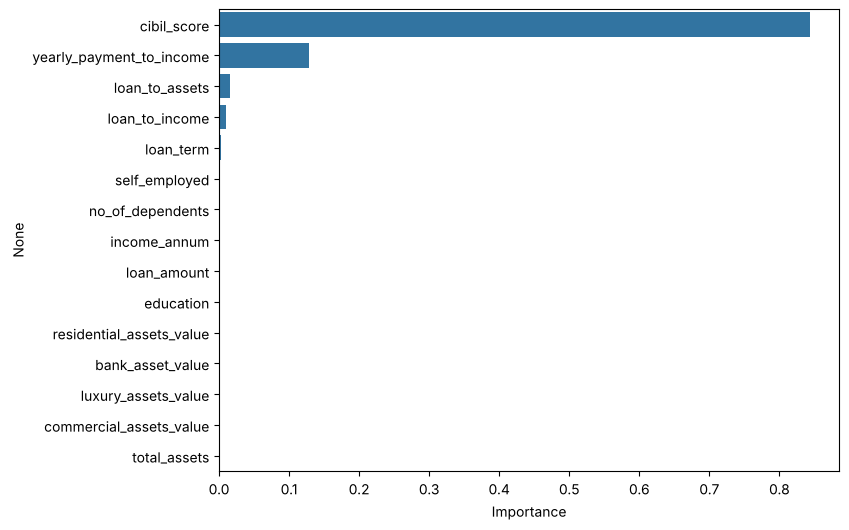

In [43]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.xlabel("Importance")
plt.show()

- **`cibil_score`** açık ara en önemli feature. Kararın büyük kısmını kredi skoru belirliyor.
- İkinci sırada bizim türettiğimiz **`yearly_payment_to_income`** var. Feature engineering'in neden bu kadar işe yaradığını burada da görüyoruz.
- Ham tutarlar (gelir, kredi tutarı, varlıklar) ile eğitim durumu, bakmakla yükümlü olunan kişi sayısı ve serbest meslek bilgisinin önemi neredeyse sıfır. EDA'da da bunların onay oranını etkilemediğini görmüştük.

Modelin karar mantığını daha iyi görmek için, sadece en önemli 2 feature ile **küçük bir karar ağacı** (derinlik 3) eğitip kurallarını yazdıralım.
Bu ağaç final model değil, sadece modelin ne öğrendiğini anlamak için:

In [44]:
from sklearn.tree import export_text

small_tree = DecisionTreeClassifier(max_depth=3, random_state=15)
small_tree.fit(X_train[["cibil_score", "yearly_payment_to_income"]], y_train)

print("Test accuracy:", round(accuracy_score(y_test, small_tree.predict(X_test[["cibil_score", "yearly_payment_to_income"]])), 4))
print(export_text(small_tree, feature_names=["cibil_score", "yearly_payment_to_income"]))

Test accuracy: 0.9731
|--- cibil_score <= 549.50
|   |--- yearly_payment_to_income <= 0.75
|   |   |--- class: 0
|   |--- yearly_payment_to_income >  0.75
|   |   |--- yearly_payment_to_income <= 1.01
|   |   |   |--- class: 1
|   |   |--- yearly_payment_to_income >  1.01
|   |   |   |--- class: 0
|--- cibil_score >  549.50
|   |--- yearly_payment_to_income <= 0.22
|   |   |--- yearly_payment_to_income <= 0.19
|   |   |   |--- class: 1
|   |   |--- yearly_payment_to_income >  0.19
|   |   |   |--- class: 1
|   |--- yearly_payment_to_income >  0.22
|   |   |--- yearly_payment_to_income <= 0.22
|   |   |   |--- class: 1
|   |   |--- yearly_payment_to_income >  0.22
|   |   |   |--- class: 1



Sadece 2 değişken ve 3 seviyelik bir ağaç bile **%97.3** doğruluk veriyor. Kurallar okunduğunda:
1. **Kredi skoru 550 üstündeyse → onay.**
2. **Kredi skoru 550 altındaysa** → yıllık taksit/gelir oranı 0.75-1.01 arasındaysa onay, değilse ret.

Final model bu iskeletin üzerine kalan küçük detayları ekleyerek %99.8'e ulaşıyor.

Bu kadar net kuralların çıkması, verinin büyük ihtimalle **sentetik** olduğunu gösteriyor: gerçek banka verilerinde bu kadar keskin sınırlar olmaz. Bu yüzden %99.8'lik başarı bu veri setine özgü. Gerçek bir banka verisinde aynı yaklaşımın bu skora ulaşması beklenmemeli. Web uygulamasında da bu notu kullanıcıya gösteriyoruz.

## 11. Modeli Kaydetme

Derste yaptığımız gibi modeli `pickle` ile kaydediyoruz. Web uygulamasının tahmin yapabilmesi için modelin yanında şunları da kaydediyoruz:
- `feature_columns`: modelin beklediği sütunlar ve **sırası**
- `education_map` ve `self_employed_map`: kategorik değerleri sayıya çeviren eşlemeler

Bunlara ek olarak, web sitesindeki "Model Hakkında" sayfasında göstermek için model sonuçlarını bir `model_info.json` dosyasına yazıyoruz. Bu dosyaya her değişkenin eğitim verisindeki min-max aralığını da ekliyoruz. Kullanıcı bu aralığın dışında bir değer girerse uygulama onu uyaracak, çünkü model o bölgeyi hiç görmedi.

In [45]:
import pickle

with open("loan_model.pkl", "wb") as f:
    pickle.dump({
        "model": final_model,
        "model_name": final_name,
        "feature_columns": list(X_train.columns),
        "education_map": education_map,
        "self_employed_map": self_employed_map
    }, f)

In [46]:
import json
import sklearn

model_info = {
    "model_name": final_name,
    "sklearn_version": sklearn.__version__,
    "dataset_size": int(len(df)),
    "approval_rate": float(y.mean()),
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "baseline_accuracy": float(baseline_accuracy),
    "test_metrics": {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall": float(recall_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "roc_auc": float(roc_auc_score(y_test, y_prob))
    },
    "confusion_matrix": cm.tolist(),
    "model_comparison": [
        {"model": name, "without_fe": float(comparison.loc[name, "FE olmadan"]), "with_fe": float(comparison.loc[name, "FE ile"])}
        for name in comparison.sort_values("FE ile", ascending=False).index
    ],
    "tuning_results": tuning_results.to_dict(orient="records"),
    "feature_importances": [{"feature": f, "importance": float(v)} for f, v in importances.items()],
    "feature_ranges": {col: [float(X_train[col].min()), float(X_train[col].max())] for col in X_train.columns}
}

with open("model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, ensure_ascii=False, indent=2)

print("Kaydedildi: loan_model.pkl, model_info.json")

Kaydedildi: loan_model.pkl, model_info.json


Kaydettiğimiz modeli tekrar yükleyip çalıştığını kontrol edelim. Web uygulamasında da tam olarak bunu yapacağız:

In [47]:
with open("loan_model.pkl", "rb") as f:
    saved = pickle.load(f)

new_application = pd.DataFrame([{
    "no_of_dependents": 2,
    "education": "Graduate",
    "self_employed": "No",
    "income_annum": 9600000,
    "loan_amount": 29900000,
    "loan_term": 12,
    "cibil_score": 778,
    "residential_assets_value": 2400000,
    "commercial_assets_value": 17600000,
    "luxury_assets_value": 22700000,
    "bank_asset_value": 8000000
}])

new_application["education"] = new_application["education"].map(saved["education_map"])
new_application["self_employed"] = new_application["self_employed"].map(saved["self_employed_map"])
new_application = add_features(new_application)[saved["feature_columns"]]

probability = saved["model"].predict_proba(new_application)[0, 1]
print(f"Onay olasılığı: %{probability * 100:.1f}")

Onay olasılığı: %99.9


## 12. Sonuç

| Adım | Ne yaptık | Sonuç |
|---|---|---|
| Veri temizliği | Sütun ve değerlerdeki boşlukları temizledik, 28 negatif konut varlığını 0 yaptık | Eksik ve tekrar eden kayıt yoktu |
| EDA | Kredi skoru 550'de keskin bir sınır bulduk; eğitim, meslek ve aile büyüklüğünün etkisi yok | Tek kuralla bile %95.8 |
| Feature engineering | 4 oran türettik, en önemlisi yıllık taksit / gelir | En iyi model %98.4 → %99.9 |
| 10 model | LR, SVM, NB, KNN, DT, RF, AdaBoost, GB, XGBoost, LightGBM | Ağaç modelleri açık ara önde |
| Transformation | Yeo-Johnson denendi | Lineer modeli düşürdü, kullanılmadı |
| Hyperparameter tuning | 6 model, RandomizedSearchCV | GB CV %99.97 |
| Final model | Gradient Boosting | **Test accuracy %99.77, ROC AUC 0.998** |

**Öğrendiklerim:**
1. **Feature engineering, model seçiminden daha önemli olabiliyor.** Doğru oranı türetmek hatayı 20 kat azalttı; tuning ise sadece binde birlik bir fark yarattı.
2. **Baseline belirlemek şart.** "%98 doğruluk" kulağa çok iyi gelse de, tek bir kuralın %95.8 verdiğini bilmeden bu sayıyı doğru değerlendiremezdik.
3. **Her teknik her veriye uymuyor.** Transformation ve Naive Bayes bu veride skoru düşürdü.
4. **Çok yüksek skor sorgulanmalı.** Kuralları çıkarınca verinin sentetik olduğu anlaşıldı.

Model `loan_model.pkl` olarak kaydedildi ve **KrediTahmin** web uygulamasında (Flask) kullanılıyor.